In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Amazon Sale Report.csv to Amazon Sale Report.csv


In [ ]:
import pandas as pd

df = pd.read_csv('Amazon Sale Report.csv')
df.head()

/tmp/ipykernel_9251/1668545406.py:3: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('Amazon Sale Report.csv')


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [ ]:
df = df.dropna(subset=['Amount', 'Qty'])

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

In [ ]:
df = df[df['Status'] == 'Shipped']

In [ ]:
df.rename(columns={
    'ship-city': 'City',
    'ship-state': 'State',
    'Qty': 'Quantity'
}, inplace=True)

In [ ]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,City,State,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.0,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.0,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
5,5,404-1490984-4578765,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,SET264,SET264-KR-NP-XL,Set,...,INR,824.0,GHAZIABAD,UTTAR PRADESH,201102.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
6,6,408-5748499-6859555,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,J0095,J0095-SET-L,Set,...,INR,653.0,CHANDIGARH,CHANDIGARH,160036.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,NaN
9,9,402-4393761-0311520,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,JNE3461,JNE3461-KR-XXL,kurta,...,INR,363.0,Chennai,TAMIL NADU,600041.0,IN,NaN,False,NaN,NaN


In [ ]:
category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)
print(category_sales)

Category
Set              25574413.0
kurta            14068674.0
Western Dress     5819859.0
Top               3811430.0
Ethnic Dress       549448.0
Blouse             323361.0
Saree               94769.0
Bottom              81386.0
Dupatta               915.0
Name: Amount, dtype: float64


In [ ]:
city_sales = df.groupby('City')['Amount'].sum().sort_values(ascending=False).head(10)
print(city_sales)

City
BENGALURU    4723666.0
HYDERABAD    3253248.0
MUMBAI       2437985.0
NEW DELHI    2347957.0
CHENNAI      2074972.0
PUNE         1535676.0
KOLKATA       943375.0
GURUGRAM      850907.0
THANE         671973.0
NOIDA         605745.0
Name: Amount, dtype: float64


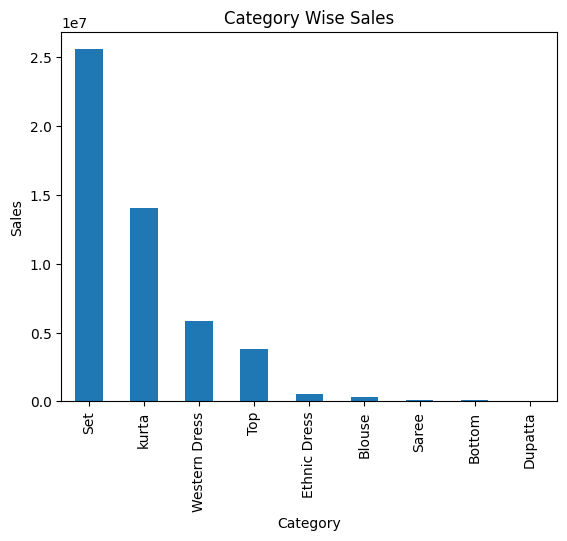

In [ ]:
import matplotlib.pyplot as plt

category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

plt.figure()
category_sales.plot(kind='bar')
plt.title("Category Wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

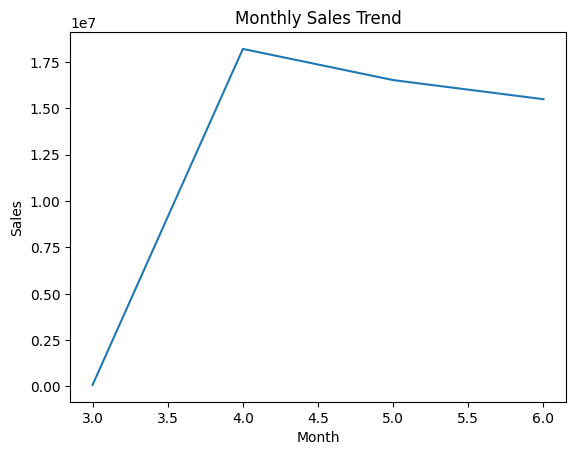

In [ ]:
df['Month'] = df['Date'].dt.month
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure()
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [ ]:
import sqlite3

conn = sqlite3.connect("amazon.db")

In [ ]:
df.to_sql("sales", conn, if_exists="replace", index=False)

77596

In [ ]:
query = """
SELECT Category, SUM(Amount) as Total_Sales
FROM sales
GROUP BY Category
ORDER BY Total_Sales DESC
"""

result = pd.read_sql(query, conn)
print(result)

        Category  Total_Sales
0            Set   25574413.0
1          kurta   14068674.0
2  Western Dress    5819859.0
3            Top    3811430.0
4   Ethnic Dress     549448.0
5         Blouse     323361.0
6          Saree      94769.0
7         Bottom      81386.0
8        Dupatta        915.0


In [ ]:
query = """
SELECT City, SUM(Amount) as Total_Sales
FROM sales
GROUP BY City
ORDER BY Total_Sales DESC
LIMIT 10
"""

result = pd.read_sql(query, conn)
print(result)

        City  Total_Sales
0  BENGALURU    4723666.0
1  HYDERABAD    3253248.0
2     MUMBAI    2437985.0
3  NEW DELHI    2347957.0
4    CHENNAI    2074972.0
5       PUNE    1535676.0
6    KOLKATA     943375.0
7   GURUGRAM     850907.0
8      THANE     671973.0
9      NOIDA     605745.0


In [ ]:
query = """
SELECT strftime('%m', Date) as Month, SUM(Amount) as Sales
FROM sales
GROUP BY Month
ORDER BY Month
"""

result = pd.read_sql(query, conn)
print(result)

  Month       Sales
0    03     84013.0
1    04  18211506.0
2    05  16530004.0
3    06  15498732.0


        City  Total_Sales
0  BENGALURU    4723666.0
1  HYDERABAD    3253248.0
2     MUMBAI    2437985.0
3  NEW DELHI    2347957.0
4    CHENNAI    2074972.0
5       PUNE    1535676.0
6    KOLKATA     943375.0
7   GURUGRAM     850907.0
8      THANE     671973.0
9      NOIDA     605745.0


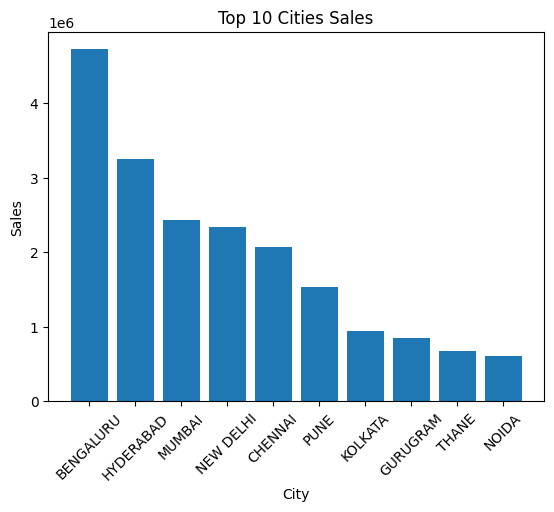

In [ ]:
import matplotlib.pyplot as plt

query = """
SELECT City, SUM(Amount) as Total_Sales
FROM sales
GROUP BY City
ORDER BY Total_Sales DESC
LIMIT 10
"""

city_data = pd.read_sql(query, conn)

print(city_data)  # output

plt.figure()
plt.bar(city_data['City'], city_data['Total_Sales'])
plt.title("Top 10 Cities Sales")
plt.xlabel("City")
plt.ylabel("Sales")
plt.xticks(rotation=45)
plt.show()

  Month       Sales
0    03     84013.0
1    04  18211506.0
2    05  16530004.0
3    06  15498732.0


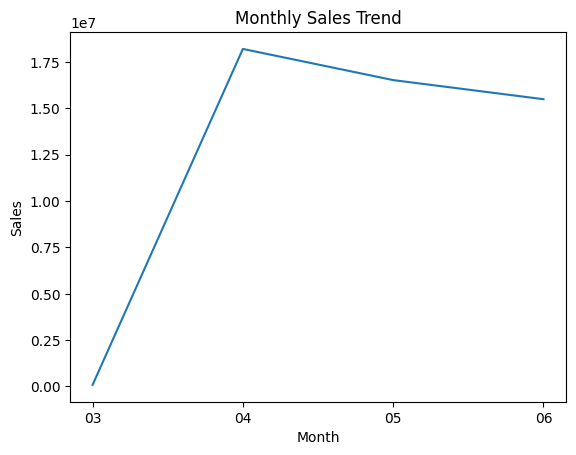

In [ ]:
query = """
SELECT strftime('%m', Date) as Month, SUM(Amount) as Sales
FROM sales
GROUP BY Month
ORDER BY Month
"""

monthly_data = pd.read_sql(query, conn)

print(monthly_data)  # output

plt.figure()
plt.plot(monthly_data['Month'], monthly_data['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [ ]:
df.to_csv("clean_amazon_data.csv", index=False)

In [ ]:
from google.colab import files
files.download("clean_amazon_data.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>